# Task 1.3, Ex-post analysis

This notebook performs the ex-post analysis.
It reuses the same scenario construction as in Task 1.1 and evaluates the offering decisions with the 8-fold cross-validation. The optimization model formulation from Task 1.1 and 1.2 is unchanged here.

Structure:

1. loads the wind, day-ahead price and system imbalance scenarios
2. builds the 1600 joint scenarios from the Cartesian product
3. splits the scenarios into 8 folds of 200 scenarios each
4. solves the in-sample offering problem for each fold under the one-price and two-price schemes
5. compares fold-by-fold and averaged in-sample versus out-of-sample expected profits
5. checks generalization of one- and two-price scheme based on averaged in-sample versus out-of-sample expected profits for modyfied in-sample sizes



In [1]:
import itertools
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

In [2]:
# =============================================================================
# Configuration
# =============================================================================
WIND_CSV = 'wind_scenarios_DK2.csv'
PRICE_CSV = 'price_scenarios_DK2.csv'
SI_CSV = 'si_scenarios.csv'

P_NOM = 500.0
BP_DEFICIT = 1.25
BP_SURPLUS = 0.85

N_FOLDS = 8
RANDOM_SEED = 42

SCHEMES_TO_RUN = ['one_price', 'two_price']

In [3]:
# =============================================================================
# Helper functions
# =============================================================================
def load_joint_scenarios(wind_csv: str, price_csv: str, si_csv: str,
                         bp_deficit: float = 1.25,
                         bp_surplus: float = 0.85):
    """
    Load the base scenario files and build the 1600 joint scenarios.

    Returns
    -------
    dict with keys:
        all_scenarios : bundled scenario matrices with keys wind, price, si and bp
        combos_df     : scenario bookkeeping table
    """
    wind_df = pd.read_csv(wind_csv, index_col='hour')
    price_df = pd.read_csv(price_csv, index_col='hour')
    si_df = pd.read_csv(si_csv, index_col='scenario')

    T = wind_df.shape[0]
    n_wind = wind_df.shape[1]
    n_price = price_df.shape[1]
    n_si = si_df.shape[0]

    combos = list(itertools.product(range(n_wind), range(n_price), range(n_si)))
    n_scen = len(combos)

    all_scenarios = {
        'wind': np.zeros((T, n_scen)),
        'price': np.zeros((T, n_scen)),
        'si': np.zeros((T, n_scen), dtype=int),
        'bp': np.zeros((T, n_scen)),
    }

    scenario_rows = []
    for omega, (w_idx, p_idx, s_idx) in enumerate(combos):
        scenario_wind = wind_df.iloc[:, w_idx].to_numpy(dtype=float)
        scenario_price = price_df.iloc[:, p_idx].to_numpy(dtype=float)
        # Match Task 1.2: cap negative DA prices to avoid negative settlement rates.
        scenario_price = np.maximum(scenario_price, 0.0)
        scenario_si = si_df.iloc[s_idx].to_numpy(dtype=int)
        scenario_bp = np.where(scenario_si == 1,
                               bp_deficit * scenario_price,
                               bp_surplus * scenario_price)

        all_scenarios['wind'][:, omega] = scenario_wind
        all_scenarios['price'][:, omega] = scenario_price
        all_scenarios['si'][:, omega] = scenario_si
        all_scenarios['bp'][:, omega] = scenario_bp

        scenario_rows.append({
            'omega': omega,
            'wind_idx': w_idx,
            'price_idx': p_idx,
            'si_idx': s_idx,
        })

    combos_df = pd.DataFrame(scenario_rows)

    return {
        'all_scenarios': all_scenarios,
        'combos_df': combos_df,
        'n_wind': n_wind,
        'n_price': n_price,
        'n_si': n_si,
        'n_scen': n_scen,
        'T': T,
    }


def make_folds(n_scen: int, n_folds: int = 8, seed: int = 42):
    """Build deterministic random folds for K-fold cross validation."""
    rng = np.random.default_rng(seed)
    perm = rng.permutation(n_scen)
    return [np.asarray(fold, dtype=int) for fold in np.array_split(perm, n_folds)]


def select_scenarios(all_scenarios: dict, indices: np.ndarray):
    """Return one scenario sample using the selected scenario indices."""
    return {
        key: matrix[:, indices]
        for key, matrix in all_scenarios.items()
    }


def settlement_matrices(sample: dict, scheme: str):
    """
    Return settlement price matrices for positive and negative imbalance.

    delta_up   = positive imbalance = wind excess = wind - offer > 0
    delta_down = negative imbalance = wind deficit = offer - wind > 0
    """
    price = sample['price']
    si = sample['si']
    bp = sample['bp']

    if scheme == 'one_price':
        price_up = bp.copy()
        price_down = bp.copy()
    elif scheme == 'two_price':
        # Desired imbalance is settled at the day ahead price.
        # Undesired imbalance is settled at the balancing price.
        # System deficit  (SI = 1): excess is desired, deficit is undesired.
        # System surplus  (SI = 0): deficit is desired, excess is undesired.
        price_up = np.where(si == 1, price, bp)
        price_down = np.where(si == 1, bp, price)
    else:
        raise ValueError(f'Unknown scheme: {scheme}')
    return price_up, price_down


def solve_offering_problem(in_sample: dict,
                           scheme: str,
                           p_nom: float = 500.0,
                           output_flag: int = 0):
    """Solve the stochastic offering problem using the in sample scenarios."""
    T, n_scen = in_sample['wind'].shape
    pi = 1.0 / n_scen
    price_up, price_down = settlement_matrices(in_sample, scheme)

    model = gp.Model(f'task1_3_{scheme}')
    model.Params.OutputFlag = output_flag
    model.Params.DualReductions = 0

    p_DA = model.addVars(T, lb=0.0, ub=p_nom, name='p_DA')
    delta_up = model.addVars(T, n_scen, lb=0.0, ub=p_nom, name='delta_up')
    delta_down = model.addVars(T, n_scen, lb=0.0, name='delta_down')

    # Same linear auxiliary-variable formulation as in Task 1.1 and Task 1.2:

    objective = gp.quicksum(
        pi * (
            in_sample['price'][t, w] * p_DA[t]
            + price_up[t, w] * delta_up[t, w]
            - price_down[t, w] * delta_down[t, w]
        )
        for t in range(T) for w in range(n_scen)
    )
    model.setObjective(objective, GRB.MAXIMIZE)

    for t in range(T):
        for w in range(n_scen):
            model.addConstr(
                delta_up[t, w] - delta_down[t, w] == in_sample['wind'][t, w] - p_DA[t],
                name=f'imbalance_t{t}_w{w}'
            )

    model.update()
    n_vars = model.NumVars
    n_constrs = model.NumConstrs

    tic = time.perf_counter()
    model.optimize()
    solve_time_s = time.perf_counter() - tic

    if model.Status != GRB.OPTIMAL:
        raise RuntimeError(f'No optimal solution found. Gurobi status: {model.Status}')

    offer = np.array([p_DA[t].X for t in range(T)])

    return {
        'offer': offer,
        'objective_value': model.ObjVal,
        'n_vars': n_vars,
        'n_constrs': n_constrs,
        'solve_time_s': solve_time_s,
    }


def evaluate_offer(offer: np.ndarray,
                   sample: dict,
                   scheme: str):
    """Evaluate a fixed day ahead offer on any evaluation sample."""
    price_up, price_down = settlement_matrices(sample, scheme)

    imbalance = sample['wind'] - offer[:, None]
    delta_up = np.maximum(imbalance, 0.0)
    delta_down = np.maximum(-imbalance, 0.0)

    scenario_profit = (
        sample['price'] * offer[:, None]
        + price_up * delta_up
        - price_down * delta_down
    ).sum(axis=0)

    return {
        'scenario_profit': scenario_profit,
        'expected_profit': float(scenario_profit.mean()),
        'std_profit': float(scenario_profit.std(ddof=0)),
        'min_profit': float(scenario_profit.min()),
        'max_profit': float(scenario_profit.max()),
        'p05_profit': float(np.percentile(scenario_profit, 5)),
        'p95_profit': float(np.percentile(scenario_profit, 95)),
    }


In [4]:
# =============================================================================
# Load data
# =============================================================================
scenario_data = load_joint_scenarios(
    WIND_CSV,
    PRICE_CSV,
    SI_CSV,
    bp_deficit=BP_DEFICIT,
    bp_surplus=BP_SURPLUS,
)

all_scenarios = scenario_data['all_scenarios']
combos_df = scenario_data['combos_df']
T = scenario_data['T']
N_SCEN = scenario_data['n_scen']
all_indices = np.arange(N_SCEN)

print(f"Joint scenarios: {scenario_data['n_wind']} wind x {scenario_data['n_price']} price x {scenario_data['n_si']} SI = {N_SCEN}")
print(f'Cross-validation folds: {N_FOLDS}')
print(f'Schemes to run: {SCHEMES_TO_RUN}')

Joint scenarios: 20 wind x 20 price x 4 SI = 1600
Cross-validation folds: 8
Schemes to run: ['one_price', 'two_price']


In [5]:
# =============================================================================
# Run Task 1.3 for 8-fold cross-validation
# =============================================================================
all_rows = []

folds = make_folds(
    n_scen=N_SCEN,
    n_folds=N_FOLDS,
    seed=RANDOM_SEED,
)

print()
print('=' * 78)
print(f'Running {N_FOLDS}-fold cross-validation | fold sizes: {[len(fold) for fold in folds]}')
print('=' * 78)

for scheme in SCHEMES_TO_RUN:
    scheme_rows_before = len(all_rows)
    print(f'  Scheme: {scheme}')

    for fold_id, in_sample_indices in enumerate(folds, start=1):
        out_of_sample_indices = np.setdiff1d(all_indices, in_sample_indices)

        in_sample = select_scenarios(all_scenarios, in_sample_indices)
        out_of_sample = select_scenarios(all_scenarios, out_of_sample_indices)

        solution = solve_offering_problem(
            in_sample=in_sample,
            scheme=scheme,
            p_nom=P_NOM,
            output_flag=0,
        )

        eval_in = evaluate_offer(
            offer=solution['offer'],
            sample=in_sample,
            scheme=scheme,
        )
        eval_out = evaluate_offer(
            offer=solution['offer'],
            sample=out_of_sample,
            scheme=scheme,
        )

        all_rows.append({
            'scheme': scheme,
            'fold': fold_id,
            'n_in_sample': len(in_sample_indices),
            'n_out_of_sample': len(out_of_sample_indices),
            'expected_profit_in_sample_EUR': eval_in['expected_profit'],
            'expected_profit_out_of_sample_EUR': eval_out['expected_profit'],
            'generalization_gap_EUR': eval_in['expected_profit'] - eval_out['expected_profit'],
            'n_vars': solution['n_vars'],
            'n_constrs': solution['n_constrs'],
            'solve_time_s': solution['solve_time_s'],
        })

    scheme_tmp = pd.DataFrame(all_rows[scheme_rows_before:])
    print(
        f"    average in sample = {scheme_tmp['expected_profit_in_sample_EUR'].mean():,.2f} EUR | "
        f"average out of sample = {scheme_tmp['expected_profit_out_of_sample_EUR'].mean():,.2f} EUR | "
        f"average runtime = {scheme_tmp['solve_time_s'].mean():,.2f} s"
    )

cv_results = pd.DataFrame(all_rows)


Running 8-fold cross-validation | fold sizes: [200, 200, 200, 200, 200, 200, 200, 200]
  Scheme: one_price
Set parameter Username
Set parameter LicenseID to value 2793120
Academic license - for non-commercial use only - expires 2027-03-16
    average in sample = 334,277.49 EUR | average out of sample = 334,277.49 EUR | average runtime = 0.05 s
  Scheme: two_price
    average in sample = 285,777.39 EUR | average out of sample = 285,511.83 EUR | average runtime = 0.08 s


In [6]:
# =============================================================================
# Summary tables
# =============================================================================
summary_df = (
    cv_results
    .groupby('scheme', as_index=False)
    .agg(
        average_expected_profit_in_sample_EUR=('expected_profit_in_sample_EUR', 'mean'),
        average_expected_profit_out_of_sample_EUR=('expected_profit_out_of_sample_EUR', 'mean'),
        average_generalization_gap_EUR=('generalization_gap_EUR', 'mean'),
        average_computational_time_s=('solve_time_s', 'mean'),
        total_computational_time_s=('solve_time_s', 'sum'),
        average_number_of_variables=('n_vars', 'mean'),
        average_number_of_constraints=('n_constrs', 'mean'),
        number_of_runs=('fold', 'count'),
    )
    .sort_values('scheme')
)

summary_df = summary_df.round(2)
cv_results_rounded = cv_results.copy()
for col in cv_results_rounded.columns:
    if cv_results_rounded[col].dtype.kind in 'fc':
        cv_results_rounded[col] = cv_results_rounded[col].round(2)

display(cv_results_rounded)
display(summary_df)

,scheme,fold,n_in_sample,n_out_of_sample,expected_profit_in_sample_EUR,expected_profit_out_of_sample_EUR,generalization_gap_EUR,n_vars,n_constrs,solve_time_s
0,one_price,1,200,1400,316089.21,336875.81,-20786.60,9624,4800,0.06
1,one_price,2,200,1400,313141.21,337296.96,-24155.75,9624,4800,0.04
2,one_price,3,200,1400,328896.70,335046.17,-6149.47,9624,4800,0.05
3,one_price,4,200,1400,342889.73,333047.17,9842.57,9624,4800,0.04
4,one_price,5,200,1400,311691.40,337504.07,-25812.68,9624,4800,0.04
5,one_price,6,200,1400,359293.16,330703.82,28589.34,9624,4800,0.04
6,one_price,7,200,1400,388969.14,326464.40,62504.74,9624,4800,0.04
7,one_price,8,200,1400,313249.36,337281.51,-24032.14,9624,4800,0.04
8,two_price,1,200,1400,267762.07,288049.31,-20287.24,9624,4800,0.08
9,two_price,2,200,1400,262202.11,288824.63,-26622.53,9624,4800,0.07


,scheme,average_expected_profit_in_sample_EUR,average_expected_profit_out_of_sample_EUR,average_generalization_gap_EUR,average_computational_time_s,total_computational_time_s,average_number_of_variables,average_number_of_constraints,number_of_runs
0,one_price,334277.49,334277.49,-0.00,0.05,0.37,9624.0,4800.0,8
1,two_price,285777.39,285511.83,265.55,0.08,0.61,9624.0,4800.0,8


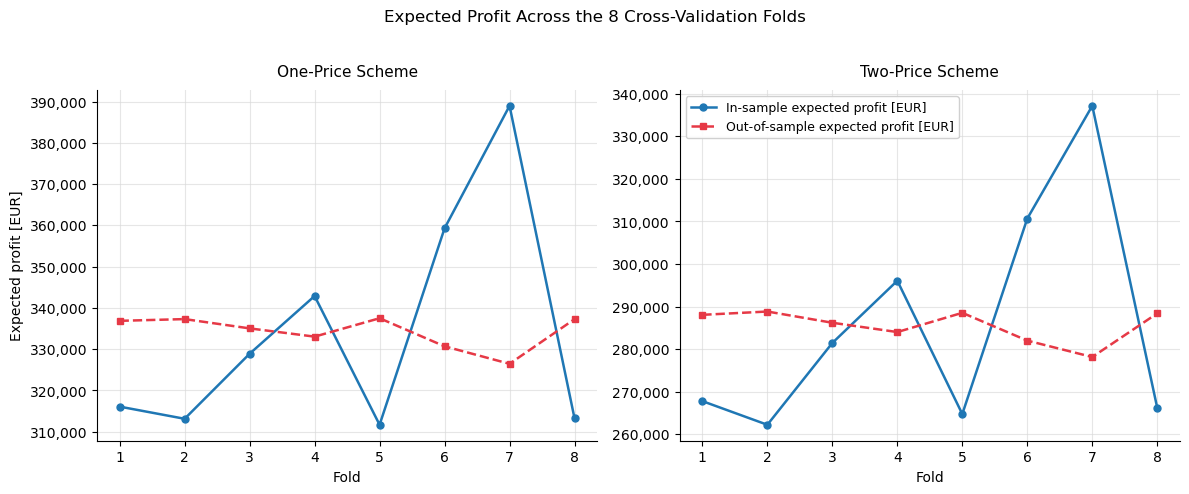

In [7]:
# =============================================================================
# Fold-by-fold expected profits for 8-fold cross-validation
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=False)

scheme_titles = {
    'one_price': 'One-Price Scheme',
    'two_price': 'Two-Price Scheme',
}

line_styles = [
    {
        'column': 'expected_profit_in_sample_EUR',
        'label': 'In-sample expected profit [EUR]',
        'color': '#1f77b4',
        'marker': 'o',
        'linestyle': '-',
    },
    {
        'column': 'expected_profit_out_of_sample_EUR',
        'label': 'Out-of-sample expected profit [EUR]',
        'color': '#e63946',
        'marker': 's',
        'linestyle': '--',
    },
]

for ax, scheme in zip(axes, SCHEMES_TO_RUN):
    tmp = cv_results.loc[cv_results['scheme'] == scheme].sort_values('fold')

    for style in line_styles:
        ax.plot(
            tmp['fold'],
            tmp[style['column']],
            marker=style['marker'],
            markersize=5,
            linewidth=1.8,
            linestyle=style['linestyle'],
            color=style['color'],
            label=style['label'],
        )

    ax.set_title(scheme_titles.get(scheme, scheme.replace('_', ' ').title()), fontsize=11, pad=10)
    ax.set_xlabel('Fold')
    ax.set_xticks(range(1, N_FOLDS + 1))
    ax.grid(True, color='#d9d9d9', linewidth=0.8, alpha=0.65)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[0].set_ylabel('Expected profit [EUR]')
axes[-1].legend(loc='best', frameon=True, framealpha=0.92, fontsize=9)

fig.suptitle('Expected Profit Across the 8 Cross-Validation Folds', fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

In [8]:
# =============================================================================
# Generalization of in-sample size: compare different numbers of folds
# =============================================================================
FOLD_COUNTS_TO_COMPARE = [2, 4, 8, 16]
kfold_rows = []

for n_folds in FOLD_COUNTS_TO_COMPARE:
    folds_k = make_folds(
        n_scen=N_SCEN,
        n_folds=n_folds,
        seed=RANDOM_SEED,
    )

    print()
    print('=' * 78)
    print(f'Generalization of in-sample size: {n_folds} folds | fold sizes: {[len(fold) for fold in folds_k]}')
    print('=' * 78)

    for scheme in SCHEMES_TO_RUN:
        scheme_rows_before = len(kfold_rows)
        print(f'  Scheme: {scheme}')

        for fold_id, in_sample_indices in enumerate(folds_k, start=1):
            out_of_sample_indices = np.setdiff1d(all_indices, in_sample_indices)

            in_sample = select_scenarios(all_scenarios, in_sample_indices)
            out_of_sample = select_scenarios(all_scenarios, out_of_sample_indices)

            solution = solve_offering_problem(
                in_sample=in_sample,
                scheme=scheme,
                p_nom=P_NOM,
                output_flag=0,
            )

            eval_in = evaluate_offer(
                offer=solution['offer'],
                sample=in_sample,
                scheme=scheme,
            )
            eval_out = evaluate_offer(
                offer=solution['offer'],
                sample=out_of_sample,
                scheme=scheme,
            )

            kfold_rows.append({
                'n_folds': n_folds,
                'scheme': scheme,
                'fold': fold_id,
                'n_in_sample': len(in_sample_indices),
                'n_out_of_sample': len(out_of_sample_indices),
                'expected_profit_in_sample_EUR': eval_in['expected_profit'],
                'expected_profit_out_of_sample_EUR': eval_out['expected_profit'],
                'generalization_gap_EUR': eval_in['expected_profit'] - eval_out['expected_profit'],
                'n_vars': solution['n_vars'],
                'n_constrs': solution['n_constrs'],
                'solve_time_s': solution['solve_time_s'],
            })

        scheme_tmp = pd.DataFrame(kfold_rows[scheme_rows_before:])
        print(
            f"    average in sample = {scheme_tmp['expected_profit_in_sample_EUR'].mean():,.2f} EUR | "
            f"average out of sample = {scheme_tmp['expected_profit_out_of_sample_EUR'].mean():,.2f} EUR | "
            f"average runtime = {scheme_tmp['solve_time_s'].mean():,.2f} s"
        )

kfold_results = pd.DataFrame(kfold_rows)

kfold_summary_df = (
    kfold_results
    .groupby(['n_folds', 'scheme'], as_index=False)
    .agg(
        average_expected_profit_in_sample_EUR=('expected_profit_in_sample_EUR', 'mean'),
        average_expected_profit_out_of_sample_EUR=('expected_profit_out_of_sample_EUR', 'mean'),
        average_generalization_gap_EUR=('generalization_gap_EUR', 'mean'),
        average_computational_time_s=('solve_time_s', 'mean'),
        average_number_of_variables=('n_vars', 'mean'),
        average_number_of_constraints=('n_constrs', 'mean'),
        average_in_sample_scenarios=('n_in_sample', 'mean'),
        average_out_of_sample_scenarios=('n_out_of_sample', 'mean'),
        number_of_runs=('fold', 'count'),
    )
    .sort_values(['n_folds', 'scheme'])
    .round(2)
)

display(kfold_summary_df)


Generalization of in-sample size: 2 folds | fold sizes: [800, 800]
  Scheme: one_price
    average in sample = 334,277.49 EUR | average out of sample = 334,277.49 EUR | average runtime = 0.22 s
  Scheme: two_price
    average in sample = 285,679.97 EUR | average out of sample = 285,596.47 EUR | average runtime = 0.27 s

Generalization of in-sample size: 4 folds | fold sizes: [400, 400, 400, 400]
  Scheme: one_price
    average in sample = 334,277.49 EUR | average out of sample = 334,277.49 EUR | average runtime = 0.09 s
  Scheme: two_price
    average in sample = 285,719.21 EUR | average out of sample = 285,546.22 EUR | average runtime = 0.18 s

Generalization of in-sample size: 8 folds | fold sizes: [200, 200, 200, 200, 200, 200, 200, 200]
  Scheme: one_price
    average in sample = 334,277.49 EUR | average out of sample = 334,277.49 EUR | average runtime = 0.04 s
  Scheme: two_price
    average in sample = 285,777.39 EUR | average out of sample = 285,511.83 EUR | average runtime = 0

,n_folds,scheme,average_expected_profit_in_sample_EUR,average_expected_profit_out_of_sample_EUR,average_generalization_gap_EUR,average_computational_time_s,average_number_of_variables,average_number_of_constraints,average_in_sample_scenarios,average_out_of_sample_scenarios,number_of_runs
0,2,one_price,334277.49,334277.49,0.00,0.22,38424.0,19200.0,800.0,800.0,2
1,2,two_price,285679.97,285596.47,83.50,0.27,38424.0,19200.0,800.0,800.0,2
2,4,one_price,334277.49,334277.49,0.00,0.09,19224.0,9600.0,400.0,1200.0,4
3,4,two_price,285719.21,285546.22,172.99,0.18,19224.0,9600.0,400.0,1200.0,4
4,8,one_price,334277.49,334277.49,-0.00,0.04,9624.0,4800.0,200.0,1400.0,8
5,8,two_price,285777.39,285511.83,265.55,0.06,9624.0,4800.0,200.0,1400.0,8
6,16,one_price,334280.62,334193.20,87.42,0.01,4824.0,2400.0,100.0,1500.0,16
7,16,two_price,285864.31,285420.53,443.78,0.02,4824.0,2400.0,100.0,1500.0,16


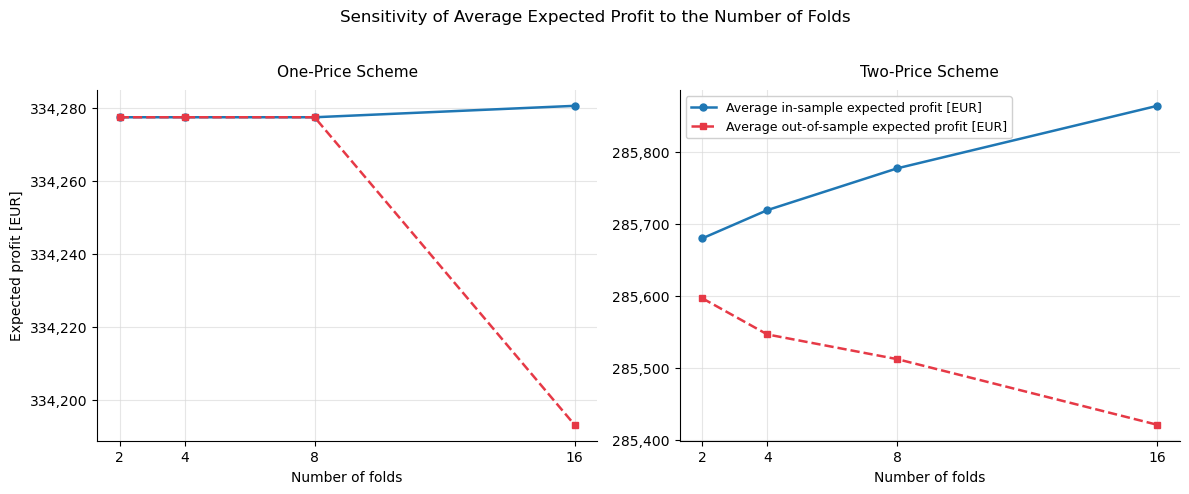

In [9]:
# =============================================================================
# Generalization of in-sample size plot: average expected profit by fold count
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=False)

scheme_titles = {
    'one_price': 'One-Price Scheme',
    'two_price': 'Two-Price Scheme',
}

line_styles = [
    {
        'column': 'average_expected_profit_in_sample_EUR',
        'label': 'Average in-sample expected profit [EUR]',
        'color': '#1f77b4',
        'marker': 'o',
        'linestyle': '-',
    },
    {
        'column': 'average_expected_profit_out_of_sample_EUR',
        'label': 'Average out-of-sample expected profit [EUR]',
        'color': '#e63946',
        'marker': 's',
        'linestyle': '--',
    },
]

for ax, scheme in zip(axes, SCHEMES_TO_RUN):
    tmp = kfold_summary_df.loc[kfold_summary_df['scheme'] == scheme].sort_values('n_folds')

    for style in line_styles:
        ax.plot(
            tmp['n_folds'],
            tmp[style['column']],
            marker=style['marker'],
            markersize=5,
            linewidth=1.8,
            linestyle=style['linestyle'],
            color=style['color'],
            label=style['label'],
        )

    ax.set_title(scheme_titles.get(scheme, scheme.replace('_', ' ').title()), fontsize=11, pad=10)
    ax.set_xlabel('Number of folds')
    ax.set_xticks(FOLD_COUNTS_TO_COMPARE)
    ax.grid(True, color='#d9d9d9', linewidth=0.8, alpha=0.65)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[0].set_ylabel('Expected profit [EUR]')
axes[-1].legend(loc='best', frameon=True, framealpha=0.92, fontsize=9)

fig.suptitle('Sensitivity of Average Expected Profit to the Number of Folds', fontsize=12, y=1.02)
fig.tight_layout()
plt.show()